# 貨幣資料收集展示

本筆記本展示如何使用 currency_predictor 模組收集貨幣匯率資料並進行基本的視覺化分析。

## 1. 匯入必要套件

In [7]:
import sys
import os

# 確保可以匯入專案模組
sys.path.append('../src')

# 匯入資料視覺化套件
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# 匯入專案模組
from currency_predictor.data.collectors import YahooFinanceCollector
from currency_predictor.data.storage import DataStorage

# 🎯 完整的全域中文字型設定
import matplotlib as mpl
from matplotlib.font_manager import FontProperties, fontManager

# 設定中文字型路徑
chinese_font_path = "D:/tools/iansui/Iansui-Regular.ttf"

# 檢查字型檔案是否存在
import os
if os.path.exists(chinese_font_path):
    print(f"✅ 找到字型檔案: {chinese_font_path}")
    
    # 創建字型屬性物件
    chinese_font = FontProperties(fname=chinese_font_path)
    font_name = chinese_font.get_name()
    
    # 方法1: 註冊字型到系統
    fontManager.addfont(chinese_font_path)
    
    # 方法2: 設定字型家族的優先順序 (關鍵!)
    mpl.rcParams['font.family'] = ['sans-serif']
    mpl.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans', 'Arial Unicode MS', 'SimHei', 'Microsoft YaHei']
    
    # 方法3: 直接設定預設字型
    plt.rcParams['font.family'] = font_name
    
    # 解決負號顯示問題
    mpl.rcParams['axes.unicode_minus'] = False
    
    print(f"✅ 已設定中文字型: {font_name}")
    print("✅ 字型設定完成，所有圖表將自動使用中文字型")
    
else:
    print(f"❌ 找不到字型檔案: {chinese_font_path}")
    print("請檢查字型檔案路徑是否正確")


# 設定圖表樣式
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

plt.rcParams['font.family'] = chinese_font.get_name()
plt.rcParams['axes.unicode_minus'] = False

print("\n所有套件匯入成功！")

✅ 找到字型檔案: D:/tools/iansui/Iansui-Regular.ttf
✅ 已設定中文字型: Iansui
✅ 字型設定完成，所有圖表將自動使用中文字型

所有套件匯入成功！


## 2. 初始化資料收集器

In [8]:
# 建立資料收集器
collector = YahooFinanceCollector()
storage = DataStorage()

print(f"支援的貨幣對: {collector.supported_pairs}")
print(f"資料儲存路徑: {storage.base_dir}")  # 修正：使用 base_dir 而不是 base_path

INFO:currency_predictor.data.collectors:Yahoo Finance 收集器已初始化
INFO:currency_predictor.data.storage:資料儲存管理器已初始化，基礎目錄: data


支援的貨幣對: ['EURUSD=X', 'GBPUSD=X', 'USDTWD=X', 'TWD=X', 'JPYUSD=X', 'AUDUSD=X', 'CADUSD=X']
資料儲存路徑: data


## 3. 檢查目標貨幣對的可用性

In [9]:
# 測試主要目標貨幣對
target_currencies = ['USDTWD=X', 'TWD=X', 'EURUSD=X']

availability_results = {}

for symbol in target_currencies:
    is_available = collector.check_symbol_availability(symbol)
    availability_results[symbol] = is_available
    status = "✅ 可用" if is_available else "❌ 不可用"
    print(f"{symbol}: {status}")

print("\n可用的貨幣對:")
available_symbols = [symbol for symbol, available in availability_results.items() if available]
print(available_symbols)

USDTWD=X: ✅ 可用
TWD=X: ✅ 可用
EURUSD=X: ✅ 可用

可用的貨幣對:
['USDTWD=X', 'TWD=X', 'EURUSD=X']


## 4. 收集一個月的匯率資料

In [10]:
# 選擇第一個可用的貨幣對進行測試
if available_symbols:
    test_symbol = available_symbols[0]
    print(f"使用貨幣對: {test_symbol}")
    
    # 收集一個月的資料
    currency_data = collector.get_currency_data(
        symbol=test_symbol,
        period="1mo",
        interval="1d"
    )
    
    if currency_data is not None:
        print(f"成功收集到 {len(currency_data)} 筆資料")
        print(f"資料時間範圍: {currency_data.index.min()} 到 {currency_data.index.max()}")
        print("\n資料概覽:")
        print(currency_data.head())
        
        print("\n資料統計:")
        print(currency_data.describe())
    else:
        print("無法取得資料")
else:
    print("沒有可用的貨幣對")

INFO:currency_predictor.data.collectors:正在取得 USDTWD=X 的資料，期間: 1mo
INFO:currency_predictor.data.collectors:成功取得 USDTWD=X 的 25 筆資料


使用貨幣對: USDTWD=X
成功收集到 25 筆資料
資料時間範圍: 2025-08-26 00:00:00+01:00 到 2025-09-27 00:00:00+01:00

資料概覽:
                                Open       High        Low      Close  Volume  \
Date                                                                            
2025-08-26 00:00:00+01:00  30.444000  30.582001  30.409500  30.444000       0   
2025-08-27 00:00:00+01:00  30.546600  30.649000  30.525299  30.546600       0   
2025-08-28 00:00:00+01:00  30.575001  30.575100  30.450001  30.575001       0   
2025-08-29 00:00:00+01:00  30.492800  30.618500  30.473000  30.492800       0   
2025-09-01 00:00:00+01:00  30.560499  30.667000  30.559299  30.560499       0   

                           Dividends  Stock Splits  
Date                                                
2025-08-26 00:00:00+01:00        0.0           0.0  
2025-08-27 00:00:00+01:00        0.0           0.0  
2025-08-28 00:00:00+01:00        0.0           0.0  
2025-08-29 00:00:00+01:00        0.0           0.0  
2025-09-01 00:00

## 5. 資料視覺化分析

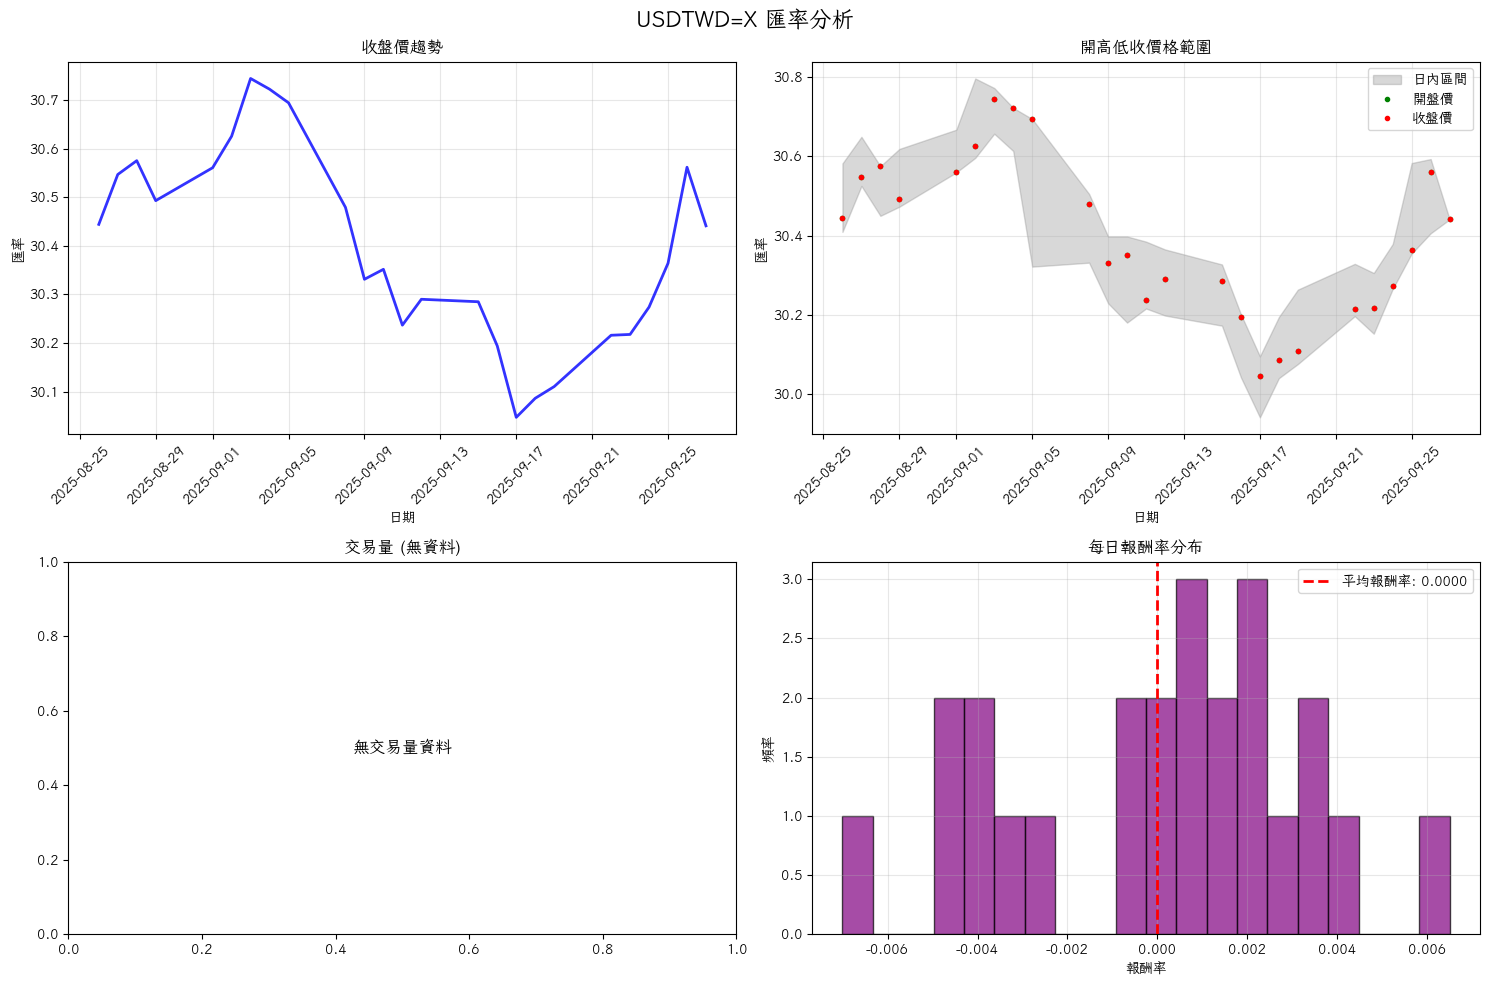

In [11]:


if currency_data is not None:
    # 建立多個子圖
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    # 現在可以直接使用中文標題，不需要 fontproperties 參數
    fig.suptitle(f'{test_symbol} 匯率分析', fontsize=16, fontweight='bold')
    
    # 1. 收盤價趨勢圖
    axes[0, 0].plot(currency_data.index, currency_data['Close'], 
                   linewidth=2, color='blue', alpha=0.8)
    axes[0, 0].set_title('收盤價趨勢')  # 直接使用中文
    axes[0, 0].set_xlabel('日期')
    axes[0, 0].set_ylabel('匯率')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. OHLC 蠟燭圖概念 (用箱型圖表示)
    daily_range = currency_data['High'] - currency_data['Low']
    axes[0, 1].fill_between(currency_data.index, 
                           currency_data['Low'], currency_data['High'],
                           alpha=0.3, color='gray', label='日內區間')
    axes[0, 1].plot(currency_data.index, currency_data['Open'], 
                   'o', markersize=3, color='green', label='開盤價')
    axes[0, 1].plot(currency_data.index, currency_data['Close'], 
                   'o', markersize=3, color='red', label='收盤價')
    axes[0, 1].set_title('開高低收價格範圍')  # 直接使用中文
    axes[0, 1].set_xlabel('日期')
    axes[0, 1].set_ylabel('匯率')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. 交易量圖
    if 'Volume' in currency_data.columns and currency_data['Volume'].sum() > 0:
        axes[1, 0].bar(currency_data.index, currency_data['Volume'], 
                      alpha=0.7, color='orange')
        axes[1, 0].set_title('交易量')  # 直接使用中文
        axes[1, 0].set_xlabel('日期')
        axes[1, 0].set_ylabel('交易量')
        axes[1, 0].tick_params(axis='x', rotation=45)
    else:
        axes[1, 0].text(0.5, 0.5, '無交易量資料', 
                       horizontalalignment='center', verticalalignment='center',
                       transform=axes[1, 0].transAxes, fontsize=12)
        axes[1, 0].set_title('交易量 (無資料)')  # 直接使用中文
    
    # 4. 每日報酬率分布
    returns = currency_data['Close'].pct_change().dropna()
    axes[1, 1].hist(returns, bins=20, alpha=0.7, color='purple', edgecolor='black')
    axes[1, 1].axvline(returns.mean(), color='red', linestyle='--', 
                      linewidth=2, label=f'平均報酬率: {returns.mean():.4f}')
    axes[1, 1].set_title('每日報酬率分布')  # 直接使用中文
    axes[1, 1].set_xlabel('報酬率')
    axes[1, 1].set_ylabel('頻率')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("無資料可供視覺化")

## 6. 基本統計分析

In [12]:
if currency_data is not None:
    # 計算基本統計指標
    returns = currency_data['Close'].pct_change().dropna()
    
    stats_data = {
        '指標': [
            '期間最高價', '期間最低價', '期間平均價', '價格標準差',
            '平均日報酬率', '報酬率標準差 (波動度)', '最大單日漲幅', '最大單日跌幅'
        ],
        '數值': [
            f"{currency_data['High'].max():.4f}",
            f"{currency_data['Low'].min():.4f}", 
            f"{currency_data['Close'].mean():.4f}",
            f"{currency_data['Close'].std():.4f}",
            f"{returns.mean():.6f}",
            f"{returns.std():.6f}",
            f"{returns.max():.6f}",
            f"{returns.min():.6f}"
        ]
    }
    
    stats_df = pd.DataFrame(stats_data)
    print(f"\n{test_symbol} 統計摘要:")
    print("=" * 40)
    for _, row in stats_df.iterrows():
        print(f"{row['指標']:<15}: {row['數值']}")
        
    # 價格變化分析
    price_change = currency_data['Close'].iloc[-1] - currency_data['Close'].iloc[0]
    price_change_pct = (currency_data['Close'].iloc[-1] / currency_data['Close'].iloc[0] - 1) * 100
    
    print("\n期間表現:")
    print(f"價格變化: {price_change:+.4f}")
    print(f"變化幅度: {price_change_pct:+.2f}%")
else:
    print("無資料可供分析")


USDTWD=X 統計摘要:
期間最高價          : 30.7960
期間最低價          : 29.9423
期間平均價          : 30.3956
價格標準差          : 0.2014
平均日報酬率         : 0.000001
報酬率標準差 (波動度)   : 0.003318
最大單日漲幅         : 0.006501
最大單日跌幅         : -0.007005

期間表現:
價格變化: -0.0030
變化幅度: -0.01%


## 7. 儲存資料到本地

In [15]:
if currency_data is not None:
    # 儲存原始資料
    success = storage.save_raw_data(
        data=currency_data,
        symbol=test_symbol.replace('=X', ''),
        period="1mo"  # 修正：使用 period 參數而不是 date_str
    )
    
    if success:
        print(f"✅ 資料已儲存到: {storage.base_dir}")  # 修正：使用 base_dir
        
        # 列出已儲存的資料
        available_data = storage.list_available_data()
        if available_data:
            print("\n已儲存的資料檔案:")
            # 修正：正確處理 available_data 的格式
            raw_files = available_data.get('raw_files', [])
            processed_files = available_data.get('processed_files', [])
            
            if raw_files:
                print("原始資料檔案:")
                for file_info in raw_files:
                    print(f"  - {file_info}")
                    
            if processed_files:
                print("處理後資料檔案:")
                for file_info in processed_files:
                    print(f"  - {file_info}")
                    
            if not raw_files and not processed_files:
                print("  - 尚無已儲存的檔案")
    else:
        print("❌ 資料儲存失敗")
else:
    print("沒有資料可供儲存")

INFO:currency_predictor.data.storage:原始資料已儲存至: data\raw\USDTWD_1mo_20250928_161447.csv
INFO:currency_predictor.data.storage:找到 1 個原始資料檔案，0 個處理後資料檔案


✅ 資料已儲存到: data

已儲存的資料檔案:
原始資料檔案:
  - USDTWD_1mo_20250928_161447.csv


## 8. 測試多個貨幣對

INFO:currency_predictor.data.collectors:正在取得 USDTWD=X 的資料，期間: 1mo
INFO:currency_predictor.data.collectors:成功取得 USDTWD=X 的 25 筆資料
INFO:currency_predictor.data.storage:原始資料已儲存至: data\raw\USDTWD_1mo_20250928_161454.csv


📥 開始下載並儲存所有需要的貨幣對資料...

正在處理 USDTWD=X...
  ✅ USDTWD=X 可用，正在下載...
  ✅ 成功下載 25 筆資料
  💾 資料已儲存到本地

正在處理 EURUSD=X...


INFO:currency_predictor.data.collectors:正在取得 EURUSD=X 的資料，期間: 1mo
INFO:currency_predictor.data.collectors:成功取得 EURUSD=X 的 24 筆資料
INFO:currency_predictor.data.storage:原始資料已儲存至: data\raw\EURUSD_1mo_20250928_161454.csv
INFO:currency_predictor.data.collectors:正在取得 EURTWD=X 的資料，期間: 1mo


  ✅ EURUSD=X 可用，正在下載...
  ✅ 成功下載 24 筆資料
  💾 資料已儲存到本地

正在處理 EURTWD=X...
  ✅ EURTWD=X 可用，正在下載...


INFO:currency_predictor.data.collectors:成功取得 EURTWD=X 的 24 筆資料
INFO:currency_predictor.data.storage:原始資料已儲存至: data\raw\EURTWD_1mo_20250928_161454.csv
INFO:currency_predictor.data.storage:找到 4 個原始資料檔案，0 個處理後資料檔案


  ✅ 成功下載 24 筆資料
  💾 資料已儲存到本地

✅ 下載完成！成功下載 3 個貨幣對

📁 檢查已儲存的資料檔案...
已儲存的原始資料檔案:
  - USDTWD_1mo_20250928_161447.csv
  - USDTWD_1mo_20250928_161454.csv
  - EURUSD_1mo_20250928_161454.csv
  - EURTWD_1mo_20250928_161454.csv

📊 從已儲存的 CSV 檔案讀取資料進行比較分析...
  ✅ 成功讀取 USDTWD 資料，共 25 筆
  ✅ 成功讀取 USDTWD 資料，共 25 筆
  ✅ 成功讀取 EURUSD 資料，共 24 筆
  ✅ 成功讀取 EURTWD 資料，共 24 筆

📈 開始繪製 3 個貨幣對的比較圖表...


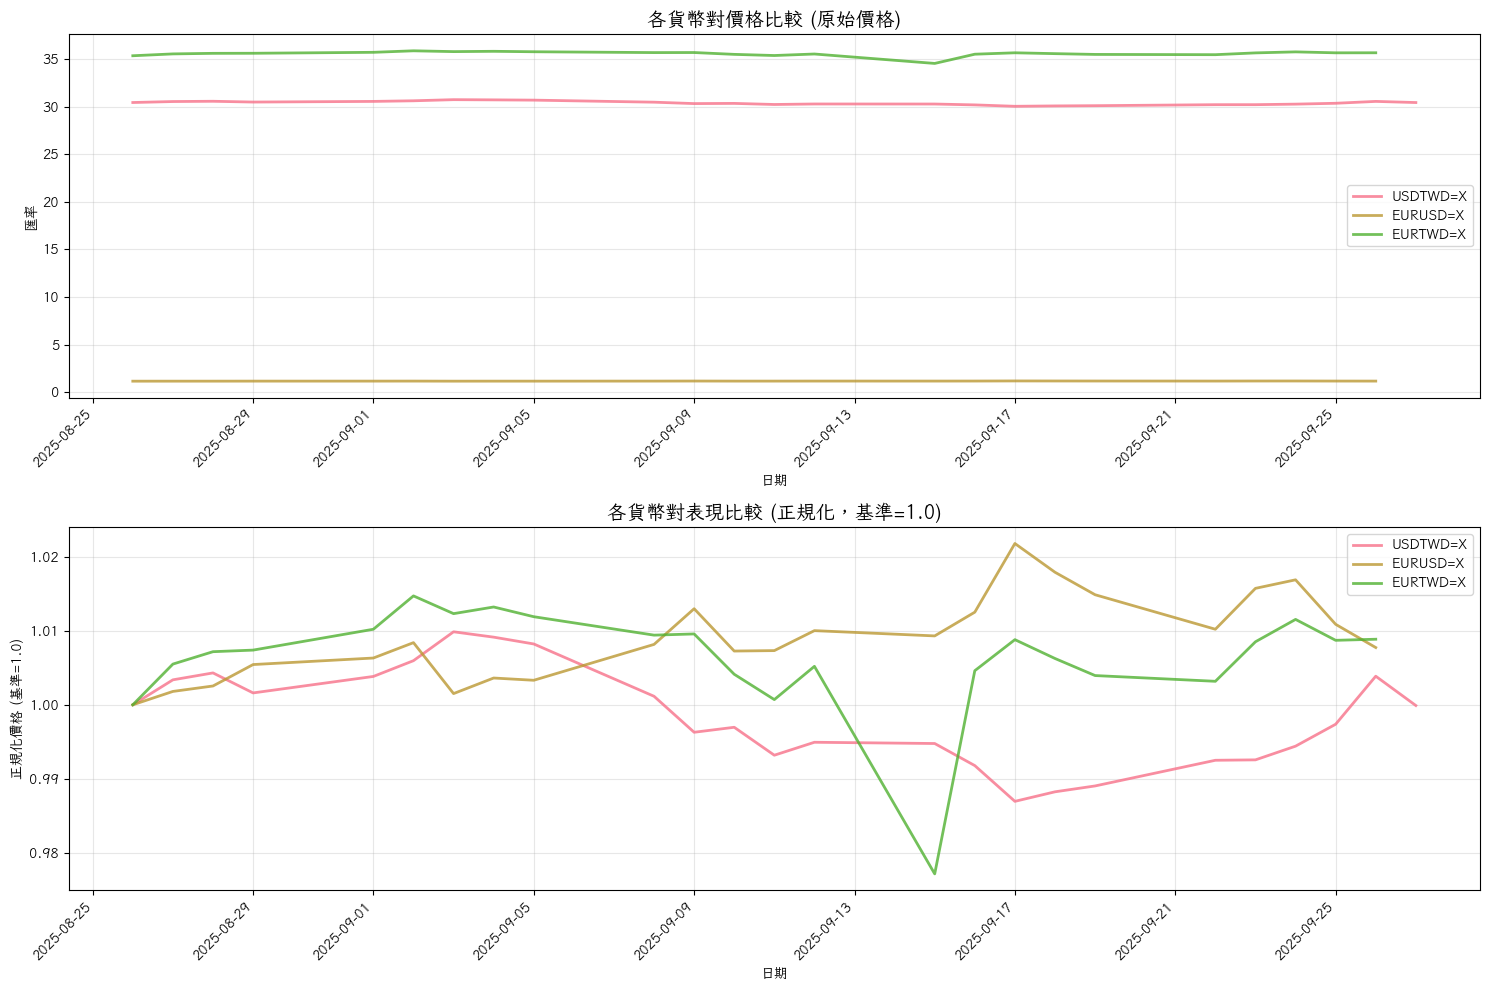


📊 各貨幣對期間表現統計:
USDTWD=X:
  起始價格: 30.4440
  結束價格: 30.4410
  報酬率: -0.01%
  年化波動率: 5.3%
----------------------------------------
EURUSD=X:
  起始價格: 1.1618
  結束價格: 1.1708
  報酬率: +0.77%
  年化波動率: 6.5%
----------------------------------------
EURTWD=X:
  起始價格: 35.3581
  結束價格: 35.6710
  報酬率: +0.89%
  年化波動率: 14.2%
----------------------------------------


In [16]:
# 下載並儲存所有需要的貨幣對資料
print("📥 開始下載並儲存所有需要的貨幣對資料...")

# 定義要下載的貨幣對
target_symbols = ['USDTWD=X', 'EURUSD=X', 'EURTWD=X']
downloaded_data = {}

for symbol in target_symbols:
    print(f"\n正在處理 {symbol}...")
    
    # 檢查可用性
    if collector.check_symbol_availability(symbol):
        print(f"  ✅ {symbol} 可用，正在下載...")
        
        # 下載資料
        data = collector.get_currency_data(symbol, period="1mo", interval="1d")
        if data is not None and not data.empty:
            print(f"  ✅ 成功下載 {len(data)} 筆資料")
            
            # 儲存到本地
            clean_symbol = symbol.replace('=X', '')
            success = storage.save_raw_data(
                data=data,
                symbol=clean_symbol,
                period="1mo"
            )
            
            if success:
                print(f"  💾 資料已儲存到本地")
                downloaded_data[symbol] = data
            else:
                print(f"  ❌ 資料儲存失敗")
        else:
            print(f"  ❌ 無法下載 {symbol} 資料")
    else:
        print(f"  ❌ {symbol} 不可用")

print(f"\n✅ 下載完成！成功下載 {len(downloaded_data)} 個貨幣對")

# 列出已儲存的檔案
print("\n📁 檢查已儲存的資料檔案...")
available_data = storage.list_available_data()
if available_data:
    raw_files = available_data.get('raw_files', [])
    if raw_files:
        print("已儲存的原始資料檔案:")
        for file_info in raw_files:
            print(f"  - {file_info}")

# 📊 從已儲存的 CSV 檔案讀取資料進行視覺化
print("\n📊 從已儲存的 CSV 檔案讀取資料進行比較分析...")

import glob
import os

# 讀取所有已儲存的 CSV 檔案
csv_files = glob.glob(os.path.join(storage.raw_dir, "*.csv"))
comparison_data = {}

for csv_file in csv_files:
    try:
        # 從檔名提取貨幣對名稱
        filename = os.path.basename(csv_file)
        symbol_name = filename.split('_')[0]  # 例如從 'USDTWD_1mo_20250928_153841.csv' 提取 'USDTWD'
        
        # 讀取 CSV 檔案
        df = pd.read_csv(csv_file, index_col=0, parse_dates=True)
        comparison_data[f"{symbol_name}=X"] = df['Close']
        print(f"  ✅ 成功讀取 {symbol_name} 資料，共 {len(df)} 筆")
        
    except Exception as e:
        print(f"  ❌ 讀取 {csv_file} 失敗: {e}")

if comparison_data:
    print(f"\n📈 開始繪製 {len(comparison_data)} 個貨幣對的比較圖表...")
    
    # 建立比較圖表
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # 上圖：原始價格比較
    for symbol, prices in comparison_data.items():
        axes[0].plot(prices.index, prices, 
                    linewidth=2, label=symbol, alpha=0.8)
    
    axes[0].set_title('各貨幣對價格比較 (原始價格)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('日期')
    axes[0].set_ylabel('匯率')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
    
    # 下圖：正規化價格比較
    for symbol, prices in comparison_data.items():
        # 正規化價格 (以第一個價格為基準)
        normalized_prices = prices / prices.iloc[0]
        axes[1].plot(normalized_prices.index, normalized_prices, 
                    linewidth=2, label=symbol, alpha=0.8)
    
    axes[1].set_title('各貨幣對表現比較 (正規化，基準=1.0)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('日期')
    axes[1].set_ylabel('正規化價格 (基準=1.0)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 各貨幣對期間表現統計:")
    print("=" * 60)
    for symbol, prices in comparison_data.items():
        period_return = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
        volatility = prices.pct_change().std() * np.sqrt(252) * 100  # 年化波動率
        
        # 顯示起始和結束價格
        start_price = prices.iloc[0]
        end_price = prices.iloc[-1]
        
        print(f"{symbol}:")
        print(f"  起始價格: {start_price:.4f}")
        print(f"  結束價格: {end_price:.4f}")
        print(f"  報酬率: {period_return:+.2f}%")
        print(f"  年化波動率: {volatility:.1f}%")
        print("-" * 40)
        
else:
    print("❌ 沒有可供比較的資料")

## 總結

本筆記本展示了 currency_predictor 資料收集模組的核心功能：

1. **初始化收集器** - 建立 YahooFinanceCollector 實例
2. **檢查可用性** - 驗證目標貨幣對是否可從 Yahoo Finance 取得資料
3. **資料收集** - 取得指定期間的 OHLCV 資料
4. **資料視覺化** - 使用 matplotlib 和 seaborn 進行多維度分析
5. **統計分析** - 計算基本的市場統計指標
6. **資料儲存** - 將收集的資料儲存到本地供後續使用
7. **多貨幣對比較** - 比較不同貨幣對的表現

### 下一步
- 實作資料預處理模組
- 建立技術指標計算功能
- 準備 PatchTST 模型所需的特徵工程